# Ładowanie danych z Kaggle
W pierwszym kroku pobieramy i rozpakowujemy przygotowane dane z serwisu Kaggle

In [ ]:
from google.colab import userdata
import os

# Retrieve only the API key from the Colab secret
kaggle_api_key = "KGAT_13e99a89ce99374acab577737d175634"

# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Write the API key to the access_token file
# This method directly writes the API key string to the file
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(kaggle_api_key)

# Set appropriate permissions for access_token
!chmod 600 /root/.kaggle/access_token

# Now you can use Kaggle CLI commands
!kaggle datasets download pawedyrda/mel-spectrogram-light
!kaggle datasets download pawedyrda/mel-spectrogram-medium
!kaggle datasets download pawedyrda/mel-spectrogram-heavy

Dataset URL: https://www.kaggle.com/datasets/pawedyrda/mel-spectrogram-light
License(s): unknown
 70% 444M/630M [00:13<00:05, 34.7MB/s] 
User cancelled operation
Dataset URL: https://www.kaggle.com/datasets/pawedyrda/mel-spectrogram-medium
License(s): unknown
 28% 691M/2.41G [00:18<00:46, 39.8MB/s] 
User cancelled operation
Dataset URL: https://www.kaggle.com/datasets/pawedyrda/mel-spectrogram-heavy
License(s): unknown
  5% 444M/9.54G [00:12<03:44, 43.6MB/s]   

  5% 467M/9.54G [00:12<04:14, 38.3MB/s]
User cancelled operation
^C


Rozpakowujemy pobrane zbiory danych do odpowienich folderów (przy mfcc12 jest błąd, tak naprawdę jest tam 40 współczynników)

In [ ]:
import os

def extract_if_empty(zip_path, dest_dir):
    if not os.path.exists(dest_dir) or not os.listdir(dest_dir):
        if os.path.exists(zip_path):
            print(f"Rozpakowywanie {zip_path} do {dest_dir}...")
            os.system(f"unzip -q {zip_path} -d {dest_dir}")
        else:
            print(f"Plik {zip_path} nie istnieje. Pomijanie.")
    else:
        print(f"Katalog {dest_dir} nie jest pusty. Pomijanie rozpakowywania.")

extract_if_empty("/content/mel-spectrogram-light.zip", "/content/mel-spectrogram-light")
extract_if_empty("/content/mel-spectrogram-medium.zip", "/content/mel-spectrogram-medium")
extract_if_empty("/content/mel-spectrogram-heavy.zip", "/content/mel-spectrogram-heavy")

Rozpakowywanie /content/mel-spectrogram-light.zip do /content/mel-spectrogram-light...
Rozpakowywanie /content/mel-spectrogram-medium.zip do /content/mel-spectrogram-medium...
Rozpakowywanie /content/mel-spectrogram-heavy.zip do /content/mel-spectrogram-heavy...


# Zbiory uczący i testowy

In [ ]:
import os
import numpy as np
import json
import re
from sklearn.model_selection import train_test_split
from dataclasses import dataclass

@dataclass
class DatasetSplits:
    train_data: np.ndarray
    train_labels_multi: np.ndarray
    train_labels_binary: np.ndarray
    val_data: np.ndarray
    val_labels_multi: np.ndarray
    val_labels_binary: np.ndarray
    test_data: np.ndarray
    test_labels_multi: np.ndarray
    test_labels_binary: np.ndarray
    classes: list

classes = [
  'ArtificialSignals',
  'BigPassengerShip',
  'Cargo',
  'FishBoat',
  'GreenCity',
  'KaiYan',
  'KaiYuan',
  'MotorBoat',
  'No7',
  'PoliceBoat',
  'QianDao',
  'SpeedBoat',
  'TheEarl',
  'TheKnight',
  'UUV',
  'Unknown',
  'WorkShip'
]

def prepare_spectrograms(spectrograms: np.ndarray) -> np.ndarray:
    """
    Convert:
        (samples, time_frames, n_mels)

    Into:
        (samples, time_frames, n_mels, 1)
    """

    spectrograms = np.asarray(spectrograms, dtype=np.float32)

    if spectrograms.ndim == 3:
        spectrograms = spectrograms[..., np.newaxis]

    if spectrograms.ndim != 4 or spectrograms.shape[-1] != 1:
        raise ValueError(
            "Expected shape "
            "(samples, time_frames, n_mels) or "
            "(samples, time_frames, n_mels, 1), "
            f"but received {spectrograms.shape}."
        )

    return spectrograms

def prepare_dataset(data_path, test_size=0.2, val_size=0.2, uuv_filter=None) -> DatasetSplits:
    X = []
    y = []

    filter_info = f" (z filtrem UUV: {uuv_filter})" if uuv_filter else ""
    print(f"Rozpoczynanie skanowania danych dla klas z: {data_path}{filter_info}")

    all_classes = sorted(list(classes))
    class_to_idx = {cls: i for i, cls in enumerate(all_classes)}
    num_classes = len(all_classes)
    uuv_idx = class_to_idx['UUV']

    files_found = 0
    files_skipped = 0

    # Second pass: load MFCCs and labels
    for root, dirs, files in os.walk(data_path):
        for filename in files:
            if filename.endswith(".npz"):
                files_found += 1

                # Apply the filter if requested
                if uuv_filter and "UUV" in filename:
                    match = re.search(r"UUV_[a-zA-Z]_([a-zA-Z])", filename)
                    if match:
                        variant = match.group(1)
                        if variant != uuv_filter:
                            files_skipped += 1
                            continue

                filepath = os.path.join(root, filename)

                try:
                    data = np.load(filepath, allow_pickle=True)
                    mfcc = data["mfcc"]
                    label_info = json.loads(str(data["label_json"]))

                    current_labels = np.zeros(num_classes, dtype=int)

                    for target in label_info["targets"]:
                        target_name = target["name"]
                        if target_name in class_to_idx:
                            current_labels[class_to_idx[target_name]] = 1

                    X.append(mfcc)
                    y.append(current_labels)

                except Exception as e:
                    print(f"Błąd przy ładowaniu pliku {filename}: {e}")

    print(f"Znaleziono plików .npz: {files_found}, Pominięto: {files_skipped}")

    if len(X) == 0:
        raise ValueError("No samples were loaded. Please check the data path and filters.")

    X = np.array(X)
    y = np.array(y)

    print(f"Załadowano {len(X)} próbek.")
    print(f"Kształt X: {X.shape}")
    print(f"Kształt y: {y.shape}")

    # First split: train+validation vs test
    train_val_data, test_data, train_val_labels, test_labels = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    # Second split: train vs validation
    train_data, val_data, train_labels, val_labels = train_test_split(
        train_val_data,
        train_val_labels,
        test_size=val_size,
        random_state=42
    )

    return DatasetSplits(
        train_data=prepare_spectrograms(train_data),
        train_labels_multi=np.asarray(train_labels, dtype=np.float32),
        train_labels_binary=np.asarray(train_labels[:, uuv_idx], dtype=np.float32),
        val_data=prepare_spectrograms(val_data),
        val_labels_multi=np.asarray(val_labels, dtype=np.float32),
        val_labels_binary=np.asarray(val_labels[:, uuv_idx], dtype=np.float32),
        test_data=prepare_spectrograms(test_data),
        test_labels_multi=np.asarray(test_labels, dtype=np.float32),
        test_labels_binary=np.asarray(test_labels[:, uuv_idx], dtype=np.float32),
        classes=all_classes
    )

Zbiory dla 10 MFCC

In [ ]:
DATA_PATH = "/content/mel-spectrogram-light"
splits_l = prepare_dataset(DATA_PATH)
train_sounds_l = splits_l.train_data
train_labels_l = splits_l.train_labels_multi
train_labels_l_bin = splits_l.train_labels_binary
val_sounds_l = splits_l.val_data
val_labels_l = splits_l.val_labels_multi
val_labels_l_bin = splits_l.val_labels_binary
test_sounds_l = splits_l.test_data
test_labels_l = splits_l.test_labels_multi
test_labels_l_bin = splits_l.test_labels_binary
all_classes_l = splits_l.classes

num_classes = len(all_classes_l)

print(f"Kształt train_sounds-l: {train_sounds_l.shape}")
print(f"Kształt test_sounds1-l: {test_sounds_l.shape}")

print("\nPreparing dataset with UUV variant 'M' (mfcc10)...")
splits_M_L = prepare_dataset(DATA_PATH, uuv_filter="M")
train_M_L = splits_M_L.train_data
train_lab_M_L = splits_M_L.train_labels_multi
train_lab_M_L_bin = splits_M_L.train_labels_binary
val_M_L = splits_M_L.val_data
val_lab_M_L = splits_M_L.val_labels_multi
val_lab_M_L_bin = splits_M_L.val_labels_binary
test_M_L = splits_M_L.test_data
test_lab_M_L = splits_M_L.test_labels_multi
test_lab_M_L_bin = splits_M_L.test_labels_binary
classes_M_L = splits_M_L.classes

print("\nPreparing dataset with UUV variant 'W' (mfcc_L)...")
splits_W_L = prepare_dataset(DATA_PATH, uuv_filter="W")
train_W_L = splits_W_L.train_data
train_lab_W_L = splits_W_L.train_labels_multi
train_lab_W_L_bin = splits_W_L.train_labels_binary
val_W_L = splits_W_L.val_data
val_lab_W_L = splits_W_L.val_labels_multi
val_lab_W_L_bin = splits_W_L.val_labels_binary
test_W_L = splits_W_L.test_data
test_lab_W_L = splits_W_L.test_labels_multi
test_lab_W_L_bin = splits_W_L.test_labels_binary
classes_W_L = splits_W_L.classes

print(f"\nTrain sounds (M) shape: {train_M_L.shape}")
print(f"Train sounds (W) shape: {train_W_L.shape}")

Rozpoczynanie skanowania danych dla klas z: /content/mel-spectrogram-light
Znaleziono plików .npz: 9674, Pominięto: 0
Załadowano 9674 próbek.
Kształt X: (9674, 309, 64)
Kształt y: (9674, 17)
Kształt train_sounds-l: (6191, 309, 64, 1)
Kształt test_sounds1-l: (1935, 309, 64, 1)

Preparing dataset with UUV variant 'M' (mfcc10)...
Rozpoczynanie skanowania danych dla klas z: /content/mel-spectrogram-light (z filtrem UUV: M)
Znaleziono plików .npz: 9674, Pominięto: 523
Załadowano 9151 próbek.
Kształt X: (9151, 309, 64)
Kształt y: (9151, 17)

Preparing dataset with UUV variant 'W' (mfcc_L)...
Rozpoczynanie skanowania danych dla klas z: /content/mel-spectrogram-light (z filtrem UUV: W)
Znaleziono plików .npz: 9674, Pominięto: 379
Załadowano 9295 próbek.
Kształt X: (9295, 309, 64)
Kształt y: (9295, 17)

Train sounds (M) shape: (5856, 309, 64, 1)
Train sounds (W) shape: (5948, 309, 64, 1)


Zbiory dla 20 MFCC

In [ ]:
DATA_PATH_MED = "/content/mel-spectrogram-medium"
print("--- Przygotowanie danych Medium ---")
splits_med = prepare_dataset(DATA_PATH_MED)
train_sounds_med = splits_med.train_data
train_labels_med = splits_med.train_labels_multi
train_labels_med_bin = splits_med.train_labels_binary
val_sounds_med = splits_med.val_data
val_labels_med = splits_med.val_labels_multi
val_labels_med_bin = splits_med.val_labels_binary
test_sounds_med = splits_med.test_data
test_labels_med = splits_med.test_labels_multi
test_labels_med_bin = splits_med.test_labels_binary
all_classes_med = splits_med.classes

print(f"\nKształt train_sounds-med: {train_sounds_med.shape}")

print("\nPreparing dataset with UUV variant 'M' (medium)...")
splits_M_med = prepare_dataset(DATA_PATH_MED, uuv_filter="M")
train_M_med = splits_M_med.train_data
train_lab_M_med = splits_M_med.train_labels_multi
train_lab_M_med_bin = splits_M_med.train_labels_binary
val_M_med = splits_M_med.val_data
val_lab_M_med = splits_M_med.val_labels_multi
val_lab_M_med_bin = splits_M_med.val_labels_binary
test_M_med = splits_M_med.test_data
test_lab_M_med = splits_M_med.test_labels_multi
test_lab_M_med_bin = splits_M_med.test_labels_binary
classes_M_med = splits_M_med.classes

print("\nPreparing dataset with UUV variant 'W' (medium)...")
splits_W_med = prepare_dataset(DATA_PATH_MED, uuv_filter="W")
train_W_med = splits_W_med.train_data
train_lab_W_med = splits_W_med.train_labels_multi
train_lab_W_med_bin = splits_W_med.train_labels_binary
val_W_med = splits_W_med.val_data
val_lab_W_med = splits_W_med.val_labels_multi
val_lab_W_med_bin = splits_W_med.val_labels_binary
test_W_med = splits_W_med.test_data
test_lab_W_med = splits_W_med.test_labels_multi
test_lab_W_med_bin = splits_W_med.test_labels_binary
classes_W_med = splits_W_med.classes


--- Przygotowanie danych Medium ---
Rozpoczynanie skanowania danych dla klas z: /content/mel-spectrogram-medium
Znaleziono plików .npz: 9674, Pominięto: 0
Załadowano 9674 próbek.
Kształt X: (9674, 618, 128)
Kształt y: (9674, 17)

Kształt train_sounds-med: (6191, 618, 128, 1)

Preparing dataset with UUV variant 'M' (medium)...
Rozpoczynanie skanowania danych dla klas z: /content/mel-spectrogram-medium (z filtrem UUV: M)
Znaleziono plików .npz: 9674, Pominięto: 523
Załadowano 9151 próbek.
Kształt X: (9151, 618, 128)
Kształt y: (9151, 17)

Preparing dataset with UUV variant 'W' (medium)...
Rozpoczynanie skanowania danych dla klas z: /content/mel-spectrogram-medium (z filtrem UUV: W)
Znaleziono plików .npz: 9674, Pominięto: 379
Załadowano 9295 próbek.
Kształt X: (9295, 618, 128)
Kształt y: (9295, 17)


Zbiory dla 40 MFCC

In [ ]:
DATA_PATH_HVY = "/content/mel-spectrogram-heavy"
print("--- Przygotowanie danych Heavy ---")
splits_hvy = prepare_dataset(DATA_PATH_HVY)
train_sounds_hvy = splits_hvy.train_data
train_labels_hvy = splits_hvy.train_labels_multi
train_labels_hvy_bin = splits_hvy.train_labels_binary
val_sounds_hvy = splits_hvy.val_data
val_labels_hvy = splits_hvy.val_labels_multi
val_labels_hvy_bin = splits_hvy.val_labels_binary
test_sounds_hvy = splits_hvy.test_data
test_labels_hvy = splits_hvy.test_labels_multi
test_labels_hvy_bin = splits_hvy.test_labels_binary
all_classes_hvy = splits_hvy.classes

print(f"\nKształt train_sounds-hvy: {train_sounds_hvy.shape}")

print("\nPreparing dataset with UUV variant 'M' (heavy)...")
splits_M_hvy = prepare_dataset(DATA_PATH_HVY, uuv_filter="M")
train_M_hvy = splits_M_hvy.train_data
train_lab_M_hvy = splits_M_hvy.train_labels_multi
train_lab_M_hvy_bin = splits_M_hvy.train_labels_binary
val_M_hvy = splits_M_hvy.val_data
val_lab_M_hvy = splits_M_hvy.val_labels_multi
val_lab_M_hvy_bin = splits_M_hvy.val_labels_binary
test_M_hvy = splits_M_hvy.test_data
test_lab_M_hvy = splits_M_hvy.test_labels_multi
test_lab_M_hvy_bin = splits_M_hvy.test_labels_binary
classes_M_hvy = splits_M_hvy.classes

print("\nPreparing dataset with UUV variant 'W' (heavy)...")
splits_W_hvy = prepare_dataset(DATA_PATH_HVY, uuv_filter="W")
train_W_hvy = splits_W_hvy.train_data
train_lab_W_hvy = splits_W_hvy.train_labels_multi
train_lab_W_hvy_bin = splits_W_hvy.train_labels_binary
val_W_hvy = splits_W_hvy.val_data
val_lab_W_hvy = splits_W_hvy.val_labels_multi
val_lab_W_hvy_bin = splits_W_hvy.val_labels_binary
test_W_hvy = splits_W_hvy.test_data
test_lab_W_hvy = splits_W_hvy.test_labels_multi
test_lab_W_hvy_bin = splits_W_hvy.test_labels_binary
classes_W_hvy = splits_W_hvy.classes


--- Przygotowanie danych Heavy ---
Rozpoczynanie skanowania danych dla klas z: /content/mel-spectrogram-heavy
Znaleziono plików .npz: 9674, Pominięto: 0
Załadowano 9674 próbek.
Kształt X: (9674, 1236, 256)
Kształt y: (9674, 17)

Kształt train_sounds-hvy: (6191, 1236, 256, 1)

Preparing dataset with UUV variant 'M' (heavy)...
Rozpoczynanie skanowania danych dla klas z: /content/mel-spectrogram-heavy (z filtrem UUV: M)
Znaleziono plików .npz: 9674, Pominięto: 523
Załadowano 9151 próbek.
Kształt X: (9151, 1236, 256)
Kształt y: (9151, 17)

Preparing dataset with UUV variant 'W' (heavy)...
Rozpoczynanie skanowania danych dla klas z: /content/mel-spectrogram-heavy (z filtrem UUV: W)
Znaleziono plików .npz: 9674, Pominięto: 379
Załadowano 9295 próbek.
Kształt X: (9295, 1236, 256)
Kształt y: (9295, 17)


# Budowa modeli CNN Multilabel

In [ ]:
from keras import callbacks, layers, metrics, models, optimizers


def build_spectrogram_cnn(
    input_shape: tuple[int, int, int],
    model_type: str = "multilabel"
) -> models.Model:
    model = models.Sequential([
      layers.Input(shape=input_shape),
      layers.Rescaling(scale=1.0 / 80.0, offset=1.0),

      layers.Conv2D(filters=32, kernel_size=(5, 5), padding="same", use_bias=False, name="conv_1"),
      layers.BatchNormalization(name="batch_norm_1"),
      layers.Activation("relu", name="relu_1"),
      layers.MaxPooling2D(pool_size=(2, 2), name="pool_1"),
      layers.SpatialDropout2D(0.15, name="spatial_dropout_1"),

      layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same", use_bias=False, name="conv_2"),
      layers.BatchNormalization(name="batch_norm_2"),
      layers.Activation("relu", name="relu_2"),
      layers.MaxPooling2D(pool_size=(2, 2), name="pool_2"),
      layers.SpatialDropout2D(0.20, name="spatial_dropout_2"),

      layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same", use_bias=False, name="conv_3"),
      layers.BatchNormalization(name="batch_norm_3"),
      layers.Activation("relu", name="relu_3"),
      layers.MaxPooling2D(pool_size=(2, 2), name="pool_3"),
      layers.SpatialDropout2D(0.30, name="spatial_dropout_3"),

      layers.Conv2D(filters=256, kernel_size=(3, 3), padding="same", use_bias=False, name="conv_4"),
      layers.BatchNormalization(name="batch_norm_4"),
      layers.Activation("relu", name="relu_4"),
      layers.GlobalAveragePooling2D(),

      layers.Dense(128, activation="relu"),
      layers.Dropout(0.40)
    ])

    if model_type == "multilabel":
        model.add(layers.Dense(num_classes, activation="sigmoid"))
    elif model_type == "binary":
        model.add(layers.Dense(1, activation="sigmoid"))
    else:
        raise ValueError("model_type must be either 'multilabel' or 'binary'")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            metrics.BinaryAccuracy(
                name="binary_accuracy",
                threshold=0.5
            ),
            metrics.AUC(
                name="roc_auc",
                curve="ROC"
            ),
            metrics.AUC(
                name="pr_auc",
                curve="PR"
            ),
            metrics.Precision(
                name="precision",
                thresholds=0.5
            ),
            metrics.Recall(
                name="recall",
                thresholds=0.5
            ),
        ]
    )

    return model

def get_cnn_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6
        )
    ]

In [ ]:
print("Building Light Models...")
model_L = build_spectrogram_cnn(input_shape=train_sounds_l.shape[1:], model_type="multilabel")
model_M_L = build_spectrogram_cnn(input_shape=train_M_L.shape[1:], model_type="multilabel")
model_W_L = build_spectrogram_cnn(input_shape=train_W_L.shape[1:], model_type="multilabel")

print("Building Medium Models...")
model_med = build_spectrogram_cnn(input_shape=train_sounds_med.shape[1:], model_type="multilabel")
model_M_med = build_spectrogram_cnn(input_shape=train_M_med.shape[1:], model_type="multilabel")
model_W_med = build_spectrogram_cnn(input_shape=train_W_med.shape[1:], model_type="multilabel")

print("Building Heavy Models...")
model_hvy = build_spectrogram_cnn(input_shape=train_sounds_hvy.shape[1:], model_type="multilabel")
model_M_hvy = build_spectrogram_cnn(input_shape=train_M_hvy.shape[1:], model_type="multilabel")
model_W_hvy = build_spectrogram_cnn(input_shape=train_W_hvy.shape[1:], model_type="multilabel")


Building Light Models...
Building Medium Models...
Building Heavy Models...


# Trenowanie modeli CNN Multilabel

In [ ]:
print("Training Base model Light...")
history10 = model_L.fit(train_sounds_l, train_labels_l, validation_data=(val_sounds_l, val_labels_l), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining M variant model Light...")
history10_M = model_M_L.fit(train_M_L, train_lab_M_L, validation_data=(val_M_L, val_lab_M_L), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining W variant model Light...")
history10_W = model_W_L.fit(train_W_L, train_lab_W_L, validation_data=(val_W_L, val_lab_W_L), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())

print("\nTraining Base model Medium...")
history_med = model_med.fit(train_sounds_med, train_labels_med, validation_data=(val_sounds_med, val_labels_med), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining M variant model Medium...")
history_M_med = model_M_med.fit(train_M_med, train_lab_M_med, validation_data=(val_M_med, val_lab_M_med), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining W variant model Medium...")
history_W_med = model_W_med.fit(train_W_med, train_lab_W_med, validation_data=(val_W_med, val_lab_W_med), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())

print("\nTraining Base model Heavy...")
history_hvy = model_hvy.fit(train_sounds_hvy, train_labels_hvy, validation_data=(val_sounds_hvy, val_labels_hvy), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining M variant model Heavy...")
history_M_hvy = model_M_hvy.fit(train_M_hvy, train_lab_M_hvy, validation_data=(val_M_hvy, val_lab_M_hvy), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining W variant model Heavy...")
history_W_hvy = model_W_hvy.fit(train_W_hvy, train_lab_W_hvy, validation_data=(val_W_hvy, val_lab_W_hvy), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())


Training Base model Light...
Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - binary_accuracy: 0.9027 - loss: 0.2570 - pr_auc: 0.2920 - precision: 0.3865 - recall: 0.2278 - roc_auc: 0.7928 - val_binary_accuracy: 0.9137 - val_loss: 0.2513 - val_pr_auc: 0.2903 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.7815 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - binary_accuracy: 0.9210 - loss: 0.2082 - pr_auc: 0.4491 - precision: 0.5812 - recall: 0.2844 - roc_auc: 0.8664 - val_binary_accuracy: 0.9158 - val_loss: 0.2215 - val_pr_auc: 0.4375 - val_precision: 0.7935 - val_recall: 0.0321 - val_roc_auc: 0.8574 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - binary_accuracy: 0.9267 - loss: 0.1912 - pr_auc: 0.5141 - precision: 0.6321 - recall: 0.3496 - roc_auc: 0.8952 - val_binary_accuracy: 0.9295 - val_loss: 0.1819 - val_pr_auc: 0.5580 - val_precision: 0.6538 - val_recall: 0.3884 - val_roc_auc: 0.9119 - learn

# Testowanie modeli CNN MultiLabel


In [ ]:
from sklearn.metrics import classification_report, f1_score

def evaluate_model(model, X_test, y_test, class_names, title):
    print(f"\n{'='*50}")
    print(f"--- Evaluation for: {title} ---")
    print(f"{'='*50}\n")
    y_prob = model.predict(X_test)
    y_pred = (y_prob >= 0.5).astype(int)

    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    print("Micro F1:", f1_score(y_test, y_pred, average="micro", zero_division=0))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro", zero_division=0))
    print("Samples F1:", f1_score(y_test, y_pred, average="samples", zero_division=0))


In [ ]:
evaluate_model(model_L, test_sounds_l, test_labels_l, all_classes_l, "Base Mel-Spectrogram Light")
evaluate_model(model_M_L, test_M_L, test_lab_M_L, classes_M_L, "M Variant Mel-Spectrogram Light")
evaluate_model(model_W_L, test_W_L, test_lab_W_L, classes_W_L, "W Variant Mel-Spectrogram Light")


--- Evaluation for: Base Mel-Spectrogram Light ---

61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
                   precision    recall  f1-score   support

ArtificialSignals       0.98      0.98      0.98       181
 BigPassengerShip       1.00      0.81      0.89        31
            Cargo       0.71      0.89      0.79        28
         FishBoat       0.85      0.95      0.90        43
        GreenCity       0.97      0.74      0.84       105
           KaiYan       0.91      1.00      0.95        20
          KaiYuan       0.92      0.84      0.88       253
        MotorBoat       1.00      0.82      0.90        17
              No7       0.92      0.80      0.86       115
       PoliceBoat       0.81      0.76      0.79        17
          QianDao       0.90      0.96      0.93       694
        SpeedBoat       0.90      0.95      0.93       819
          TheEarl       0.98      0.97      0.98       107
        TheKnight       0.90      0.93      0.92        60
              UUV    

In [ ]:
evaluate_model(model_med, test_sounds_med, test_labels_med, all_classes_med, "Base Mel-Spectrogram Medium")
evaluate_model(model_M_med, test_M_med, test_lab_M_med, classes_M_med, "M Variant Mel-Spectrogram Medium")
evaluate_model(model_W_med, test_W_med, test_lab_W_med, classes_W_med, "W Variant Mel-Spectrogram Medium")



--- Evaluation for: Base Mel-Spectrogram Medium ---

61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
                   precision    recall  f1-score   support

ArtificialSignals       0.99      0.97      0.98       181
 BigPassengerShip       0.84      0.87      0.86        31
            Cargo       0.75      0.54      0.62        28
         FishBoat       1.00      0.44      0.61        43
        GreenCity       0.95      0.52      0.67       105
           KaiYan       0.90      0.95      0.93        20
          KaiYuan       0.87      0.55      0.67       253
        MotorBoat       1.00      0.71      0.83        17
              No7       0.89      0.56      0.68       115
       PoliceBoat       0.79      0.65      0.71        17
          QianDao       0.85      0.92      0.88       694
        SpeedBoat       0.85      0.88      0.86       819
          TheEarl       0.97      0.91      0.94       107
        TheKnight       0.76      0.83      0.79        60
              UUV   

In [ ]:
evaluate_model(model_hvy, test_sounds_hvy, test_labels_hvy, all_classes_hvy, "Base Mel-Spectrogram Heavy")
evaluate_model(model_M_hvy, test_M_hvy, test_lab_M_hvy, classes_M_hvy, "M Variant Mel-Spectrogram Heavy")
evaluate_model(model_W_hvy, test_W_hvy, test_lab_W_hvy, classes_W_hvy, "W Variant Mel-Spectrogram Heavy")



--- Evaluation for: Base Mel-Spectrogram Heavy ---

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step
                   precision    recall  f1-score   support

ArtificialSignals       0.99      0.84      0.91       181
 BigPassengerShip       0.00      0.00      0.00        31
            Cargo       0.00      0.00      0.00        28
         FishBoat       0.87      0.30      0.45        43
        GreenCity       0.93      0.26      0.40       105
           KaiYan       0.00      0.00      0.00        20
          KaiYuan       0.68      0.29      0.41       253
        MotorBoat       0.79      0.65      0.71        17
              No7       0.83      0.37      0.51       115
       PoliceBoat       0.73      0.65      0.69        17
          QianDao       0.80      0.81      0.80       694
        SpeedBoat       0.76      0.80      0.78       819
          TheEarl       0.93      0.78      0.85       107
        TheKnight       0.88      0.62      0.73        60
              UUV    

# Analiza wyników dla klasy UUV
W tej sekcji skupiamy się wyłącznie na wynikach osiąganych przez klasę `UUV` w zależności od wariantu zbioru danych (Base, M, W) oraz wariantu zbioru spektrogramów.

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
from IPython.display import display

def get_uuv_metrics(model, X_test, y_test, class_names, model_name):
    y_prob = model.predict(X_test, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int)

    # Generate dict report to extract specific class
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)

    # Find the exact key for UUV
    uuv_key = next((key for key in report.keys() if 'UUV' in key), None)

    if uuv_key:
        metrics = report[uuv_key]
        metrics['Model'] = model_name
        return metrics
    return None

configs = [
    (model_L, test_sounds_l, test_labels_l, all_classes_l, "Base Mel-Spectrogram Light"),
    (model_M_L, test_M_L, test_lab_M_L, classes_M_L, "M Variant Mel-Spectrogram Light"),
    (model_W_L, test_W_L, test_lab_W_L, classes_W_L, "W Variant Mel-Spectrogram Light"),
    (model_med, test_sounds_med, test_labels_med, all_classes_med, "Base Mel-Spectrogram Medium"),
    (model_M_med, test_M_med, test_lab_M_med, classes_M_med, "M Variant Mel-Spectrogram Medium"),
    (model_W_med, test_W_med, test_lab_W_med, classes_W_med, "W Variant Mel-Spectrogram Medium"),
    (model_hvy, test_sounds_hvy, test_labels_hvy, all_classes_hvy, "Base Mel-Spectrogram Heavy"),
    (model_M_hvy, test_M_hvy, test_lab_M_hvy, classes_M_hvy, "M Variant Mel-Spectrogram Heavy"),
    (model_W_hvy, test_W_hvy, test_lab_W_hvy, classes_W_hvy, "W Variant Mel-Spectrogram Heavy"),
]

uuv_results = []
for config in configs:
    res = get_uuv_metrics(*config)
    if res:
        uuv_results.append(res)

df_uuv = pd.DataFrame(uuv_results)
# Reorder columns for readability
df_uuv = df_uuv[['Model', 'precision', 'recall', 'f1-score', 'support']]

print("Tabela wyników dla klasy UUV:")
display(df_uuv)


Tabela wyników dla klasy UUV:


,Model,precision,recall,f1-score,support
0,Base Mel-Spectrogram Light,0.982249,0.976471,0.979351,170.0
1,M Variant Mel-Spectrogram Light,1.000000,0.985294,0.992593,68.0
2,W Variant Mel-Spectrogram Light,0.990566,0.990566,0.990566,106.0
3,Base Mel-Spectrogram Medium,0.993976,0.970588,0.982143,170.0
4,M Variant Mel-Spectrogram Medium,0.985075,0.970588,0.977778,68.0
5,W Variant Mel-Spectrogram Medium,0.867769,0.990566,0.925110,106.0
6,Base Mel-Spectrogram Heavy,0.953020,0.835294,0.890282,170.0
7,M Variant Mel-Spectrogram Heavy,0.982759,0.838235,0.904762,68.0
8,W Variant Mel-Spectrogram Heavy,0.815217,0.707547,0.757576,106.0


<Figure size 1400x600 with 0 Axes>

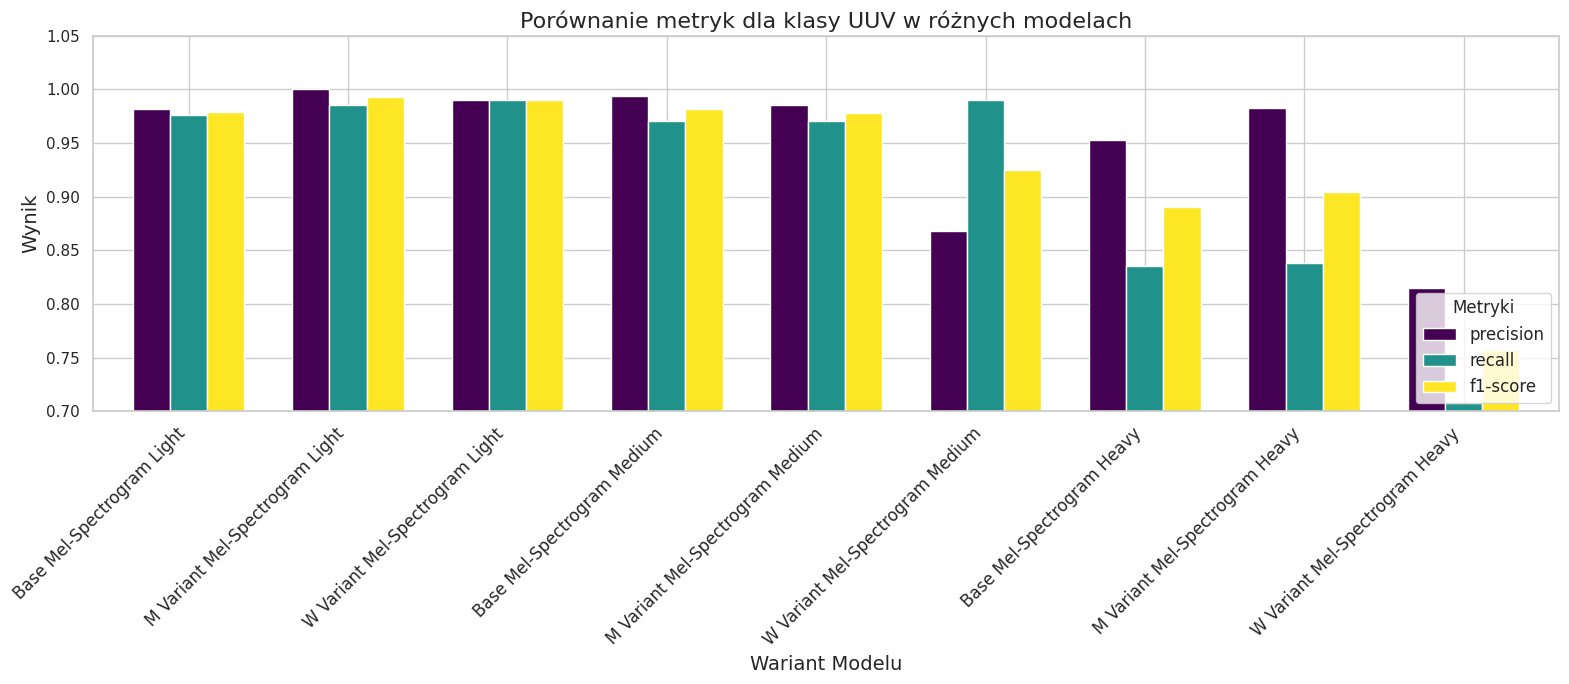

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia stylu
sns.set_theme(style="whitegrid")

# Wykres słupkowy dla Precision, Recall i F1-score
plt.figure(figsize=(14, 6))
ax = df_uuv.set_index('Model')[['precision', 'recall', 'f1-score']].plot(
    kind='bar', figsize=(16, 7), colormap='viridis', width=0.7
)

plt.title('Porównanie metryk dla klasy UUV w różnych modelach', fontsize=16)
plt.ylabel('Wynik', fontsize=14)
plt.xlabel('Wariant Modelu', fontsize=14)
plt.ylim(0.7, 1.05)  # Zoom in on the top values since models perform very well
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.legend(title="Metryki", loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

### Wizualizacja procesu uczenia (Całkowity Loss i AUC)
Poniższe wykresy prezentują przebieg uczenia całych modeli dla poszczególnych wariantów i wymiarów danych MFCC.

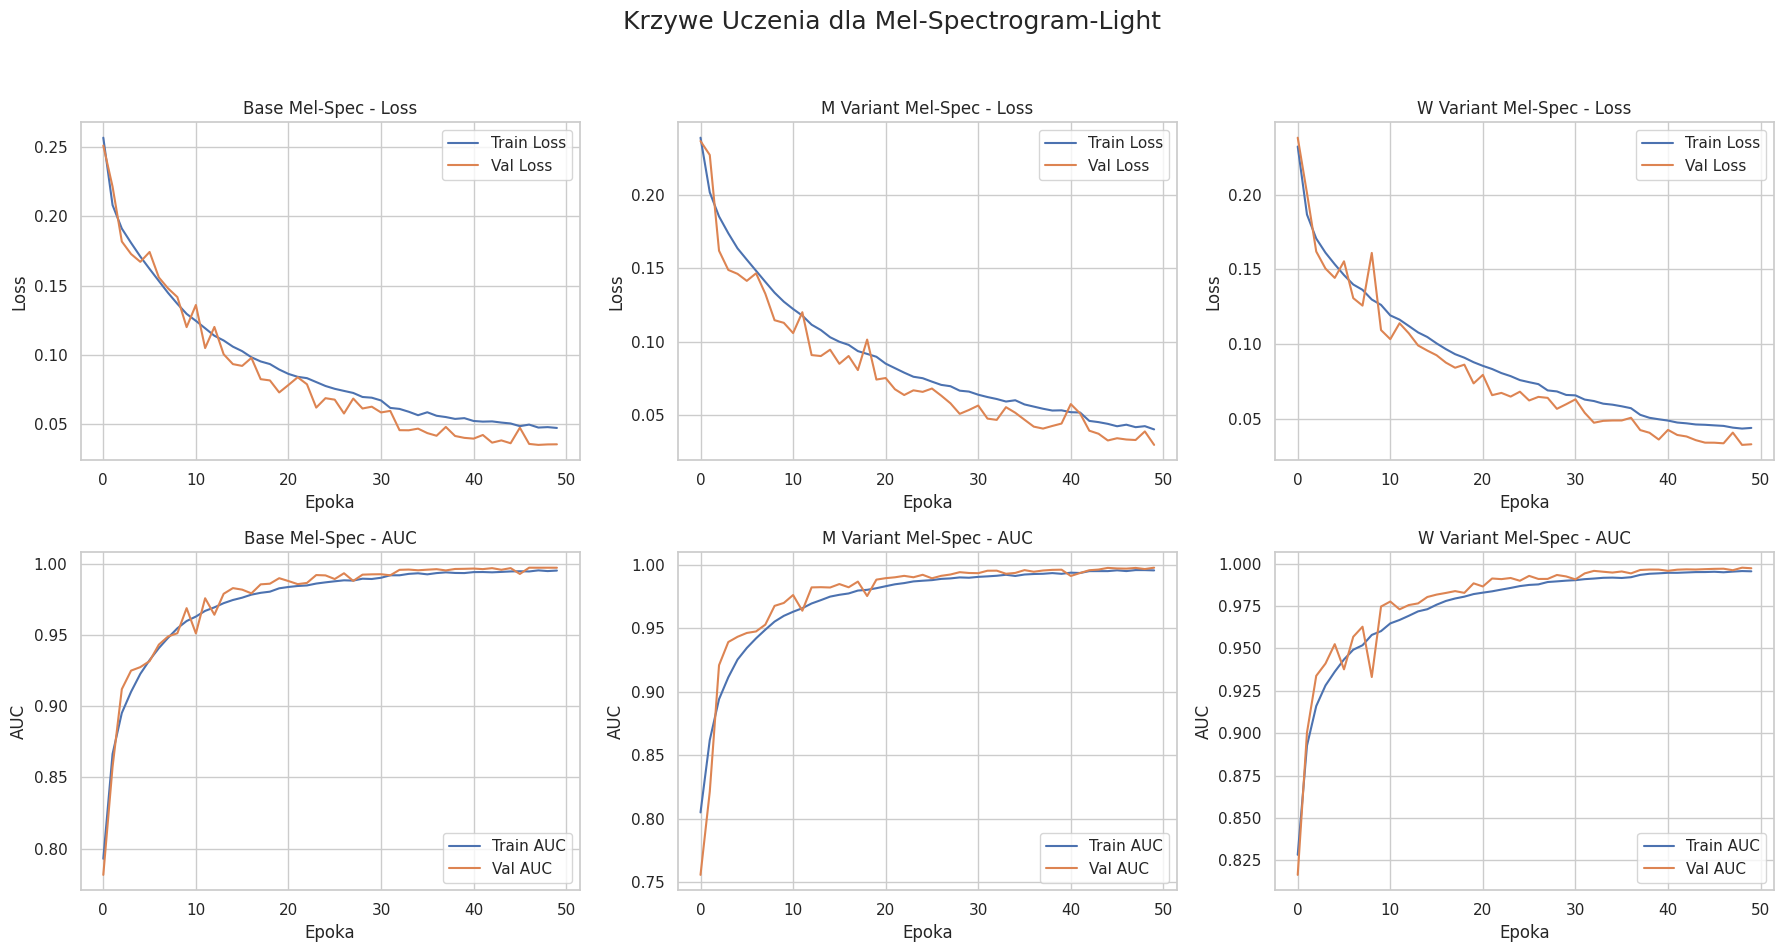

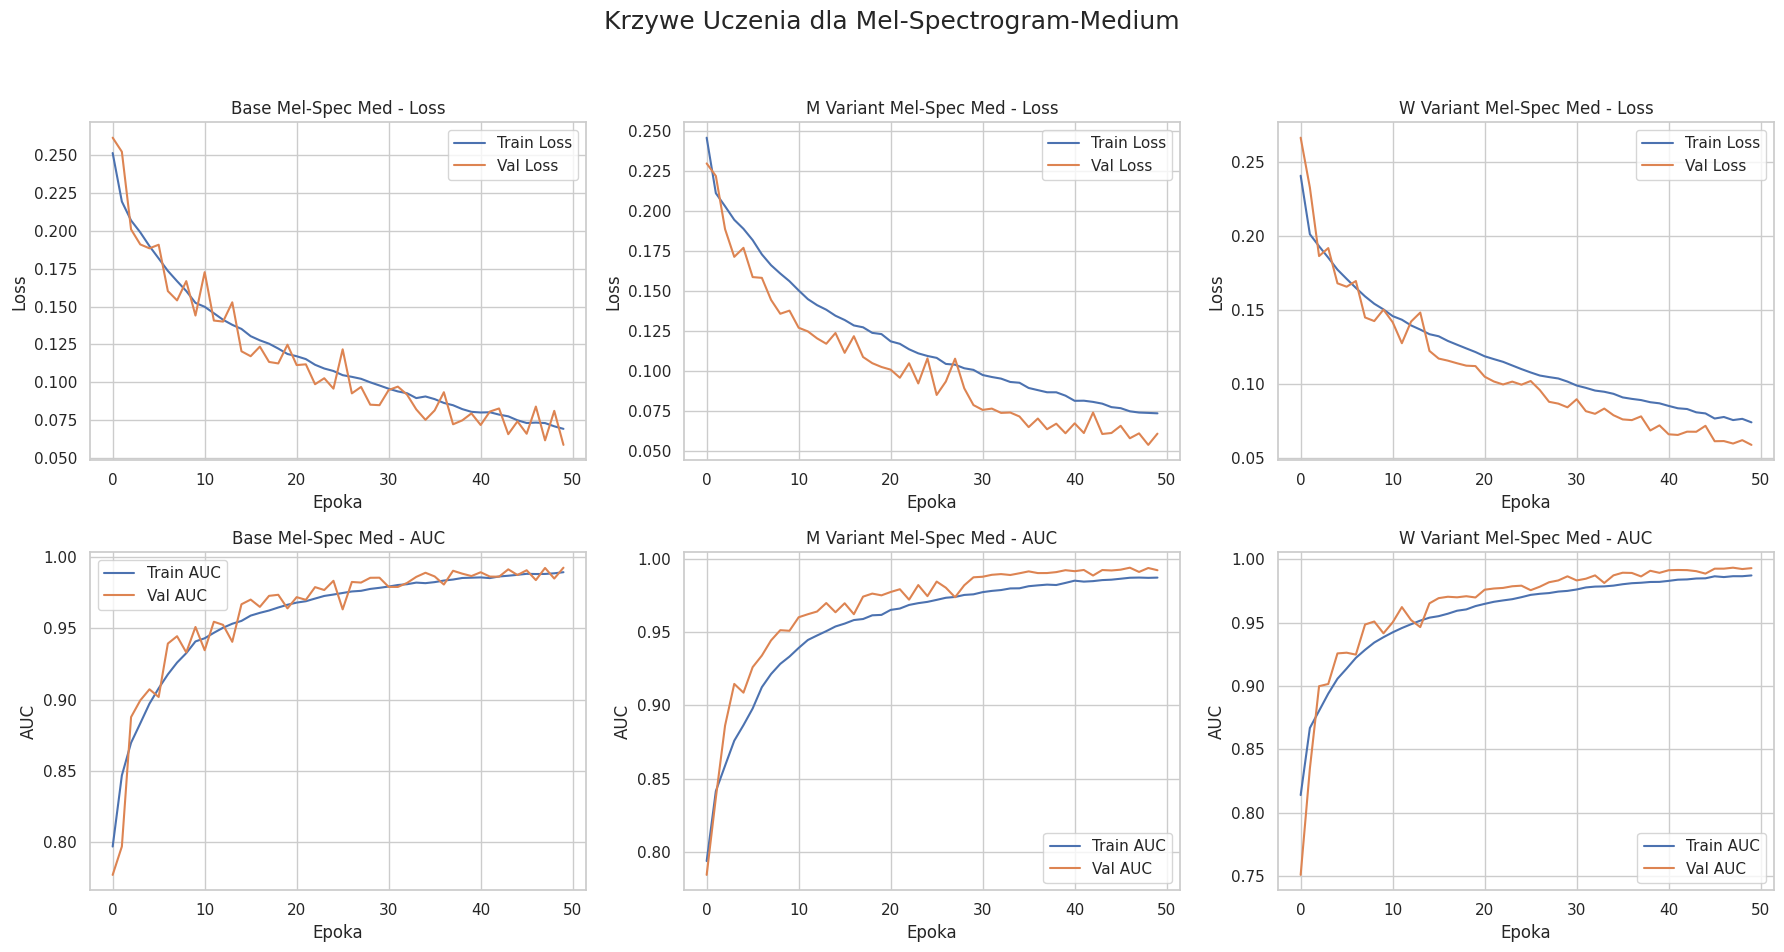

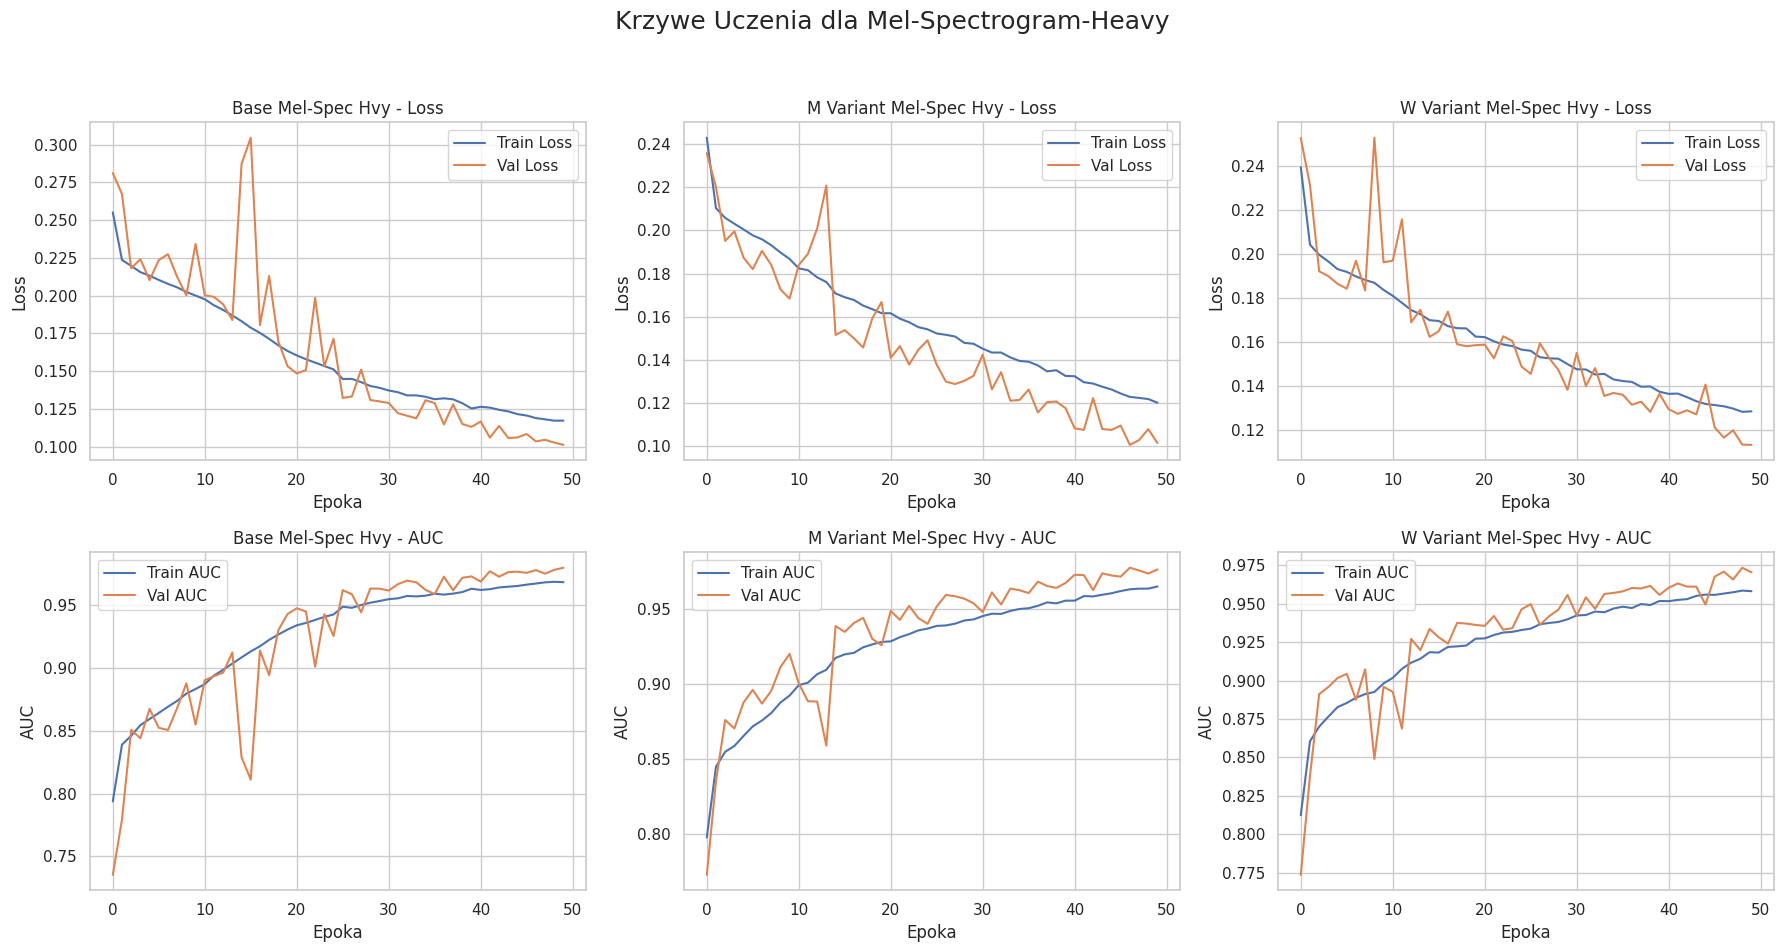

In [ ]:
def plot_training_histories(histories, titles, mfcc_label):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Krzywe Uczenia dla {mfcc_label}', fontsize=18)

    for i, (history, title) in enumerate(zip(histories, titles)):
        # Loss
        axes[0, i].plot(history.history['loss'], label='Train Loss')
        axes[0, i].plot(history.history['val_loss'], label='Val Loss')
        axes[0, i].set_title(f'{title} - Loss')
        axes[0, i].set_xlabel('Epoka')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].legend()

        # AUC (changed 'auc' to 'roc_auc' based on metrics compilation)
        axes[1, i].plot(history.history['roc_auc'], label='Train AUC')
        axes[1, i].plot(history.history['val_roc_auc'], label='Val AUC')
        axes[1, i].set_title(f'{title} - AUC')
        axes[1, i].set_xlabel('Epoka')
        axes[1, i].set_ylabel('AUC')
        axes[1, i].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Wykresy dla Mel-Spectrogram-Light
plot_training_histories(
    [history10, history10_M, history10_W],
    ['Base Mel-Spec', 'M Variant Mel-Spec', 'W Variant Mel-Spec'],
    'Mel-Spectrogram-Light'
)

# Wykresy dla Mel-Spectrogram-Medium
plot_training_histories(
    [history_med, history_M_med, history_W_med],
    ['Base Mel-Spec Med', 'M Variant Mel-Spec Med', 'W Variant Mel-Spec Med'],
    'Mel-Spectrogram-Medium'
)

# Wykresy dla Mel-Spectrogram-Heavy
plot_training_histories(
    [history_hvy, history_M_hvy, history_W_hvy],
    ['Base Mel-Spec Hvy', 'M Variant Mel-Spec Hvy', 'W Variant Mel-Spec Hvy'],
    'Mel-Spectrogram-Heavy'
)


# Budowa modeli CNN Binary (0 - No UUV, 1 - UUV)
Poniższe modele używają tej samej funkcji `build_spectrogram_cnn`, ale z wyjściem binarnym dla detekcji klasy UUV.

In [ ]:
print("Building Binary Light Models...")
bin_model_L = build_spectrogram_cnn(input_shape=train_sounds_l.shape[1:], model_type="binary")
bin_model_M_L = build_spectrogram_cnn(input_shape=train_M_L.shape[1:], model_type="binary")
bin_model_W_L = build_spectrogram_cnn(input_shape=train_W_L.shape[1:], model_type="binary")

print("Building Binary Medium Models...")
bin_model_med = build_spectrogram_cnn(input_shape=train_sounds_med.shape[1:], model_type="binary")
bin_model_M_med = build_spectrogram_cnn(input_shape=train_M_med.shape[1:], model_type="binary")
bin_model_W_med = build_spectrogram_cnn(input_shape=train_W_med.shape[1:], model_type="binary")

print("Building Binary Heavy Models...")
bin_model_hvy = build_spectrogram_cnn(input_shape=train_sounds_hvy.shape[1:], model_type="binary")
bin_model_M_hvy = build_spectrogram_cnn(input_shape=train_M_hvy.shape[1:], model_type="binary")
bin_model_W_hvy = build_spectrogram_cnn(input_shape=train_W_hvy.shape[1:], model_type="binary")


## Trenowanie modeli Binarnych

In [ ]:
print("Training Binary Base model Light...")
bin_hist_L = bin_model_L.fit(train_sounds_l, train_labels_l_bin, validation_data=(val_sounds_l, val_labels_l_bin), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining Binary M variant model Light...")
bin_hist_M_L = bin_model_M_L.fit(train_M_L, train_lab_M_L_bin, validation_data=(val_M_L, val_lab_M_L_bin), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining Binary W variant model Light...")
bin_hist_W_L = bin_model_W_L.fit(train_W_L, train_lab_W_L_bin, validation_data=(val_W_L, val_lab_W_L_bin), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())

print("\nTraining Binary Base model Medium...")
bin_hist_med = bin_model_med.fit(train_sounds_med, train_labels_med_bin, validation_data=(val_sounds_med, val_labels_med_bin), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining Binary M variant model Medium...")
bin_hist_M_med = bin_model_M_med.fit(train_M_med, train_lab_M_med_bin, validation_data=(val_M_med, val_lab_M_med_bin), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining Binary W variant model Medium...")
bin_hist_W_med = bin_model_W_med.fit(train_W_med, train_lab_W_med_bin, validation_data=(val_W_med, val_lab_W_med_bin), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())

print("\nTraining Binary Base model Heavy...")
bin_hist_hvy = bin_model_hvy.fit(train_sounds_hvy, train_labels_hvy_bin, validation_data=(val_sounds_hvy, val_labels_hvy_bin), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining Binary M variant model Heavy...")
bin_hist_M_hvy = bin_model_M_hvy.fit(train_M_hvy, train_lab_M_hvy_bin, validation_data=(val_M_hvy, val_lab_M_hvy_bin), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())
print("\nTraining Binary W variant model Heavy...")
bin_hist_W_hvy = bin_model_W_hvy.fit(train_W_hvy, train_lab_W_hvy_bin, validation_data=(val_W_hvy, val_lab_W_hvy_bin), epochs=50, batch_size=32, callbacks=get_cnn_callbacks())


## Testowanie modeli Binarnych

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

def evaluate_binary_model(model, X_test, y_test, title):
    print(f"\n{'='*50}")
    print(f"--- Evaluation for: {title} ---")
    print(f"{'='*50}\n")
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_true = np.asarray(y_test).ravel().astype(int)
    y_pred = (y_prob >= 0.5).astype(int)

    print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["No UUV", "UUV"], zero_division=0))
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["No UUV", "UUV"],
        output_dict=True,
        zero_division=0
    )
    uuv_metrics = report["UUV"]
    return {
        "Model": title,
        "precision": uuv_metrics["precision"],
        "recall": uuv_metrics["recall"],
        "f1-score": uuv_metrics["f1-score"],
        "support": uuv_metrics["support"],
    }

binary_configs = [
    (bin_model_L, test_sounds_l, test_labels_l_bin, "Binary Base Mel-Spectrogram Light"),
    (bin_model_M_L, test_M_L, test_lab_M_L_bin, "Binary M Variant Mel-Spectrogram Light"),
    (bin_model_W_L, test_W_L, test_lab_W_L_bin, "Binary W Variant Mel-Spectrogram Light"),
    (bin_model_med, test_sounds_med, test_labels_med_bin, "Binary Base Mel-Spectrogram Medium"),
    (bin_model_M_med, test_M_med, test_lab_M_med_bin, "Binary M Variant Mel-Spectrogram Medium"),
    (bin_model_W_med, test_W_med, test_lab_W_med_bin, "Binary W Variant Mel-Spectrogram Medium"),
    (bin_model_hvy, test_sounds_hvy, test_labels_hvy_bin, "Binary Base Mel-Spectrogram Heavy"),
    (bin_model_M_hvy, test_M_hvy, test_lab_M_hvy_bin, "Binary M Variant Mel-Spectrogram Heavy"),
    (bin_model_W_hvy, test_W_hvy, test_lab_W_hvy_bin, "Binary W Variant Mel-Spectrogram Heavy"),
]

binary_results = [evaluate_binary_model(*config) for config in binary_configs]
df_binary_uuv = pd.DataFrame(binary_results)
print("Tabela wyników dla binarnej detekcji UUV:")
display(df_binary_uuv)


# Zapisywanie modeli i wyników (Zabezpieczenie postępów)
Poniższy kod zapisuje wszystkie wytrenowane modele, ich historie uczenia oraz tabelę z wynikami ewaluacji na dysk, a następnie pakuje je do archiwum ZIP, które można pobrać na komputer.

In [ ]:
import os
import pickle
import shutil
from google.colab import files

# Utworzenie folderu na zapisane dane
save_dir = 'saved_artifacts'
os.makedirs(save_dir, exist_ok=True)

print("Zapisywanie modeli...")
# Zapis modeli dla Mel-Spectrogram Light
model_L.save(f'{save_dir}/model_light_base.keras')
model_M_L.save(f'{save_dir}/model_light_M.keras')
model_W_L.save(f'{save_dir}/model_light_W.keras')

# Zapis modeli dla Mel-Spectrogram Medium
model_med.save(f'{save_dir}/model_med_base.keras')
model_M_med.save(f'{save_dir}/model_med_M.keras')
model_W_med.save(f'{save_dir}/model_med_W.keras')

# Zapis modeli dla Mel-Spectrogram Heavy
model_hvy.save(f'{save_dir}/model_hvy_base.keras')
model_M_hvy.save(f'{save_dir}/model_hvy_M.keras')
model_W_hvy.save(f'{save_dir}/model_hvy_W.keras')

# Zapis binarnych modeli dla detekcji UUV
bin_model_L.save(f'{save_dir}/bin_model_light_base.keras')
bin_model_M_L.save(f'{save_dir}/bin_model_light_M.keras')
bin_model_W_L.save(f'{save_dir}/bin_model_light_W.keras')
bin_model_med.save(f'{save_dir}/bin_model_med_base.keras')
bin_model_M_med.save(f'{save_dir}/bin_model_med_M.keras')
bin_model_W_med.save(f'{save_dir}/bin_model_med_W.keras')
bin_model_hvy.save(f'{save_dir}/bin_model_hvy_base.keras')
bin_model_M_hvy.save(f'{save_dir}/bin_model_hvy_M.keras')
bin_model_W_hvy.save(f'{save_dir}/bin_model_hvy_W.keras')

print("Modele zostały zapisane w formacie .keras.")

Zapisywanie modeli...
Modele zostały zapisane w formacie .keras.


In [ ]:
print("Zapisywanie historii uczenia i wyników ewaluacji...")

# Zapis historii do słownika
histories_dict = {
    'history_light_base': history10.history,
    'history_light_M': history10_M.history,
    'history_light_W': history10_W.history,
    'history_med_base': history_med.history,
    'history_med_M': history_M_med.history,
    'history_med_W': history_W_med.history,
    'history_hvy_base': history_hvy.history,
    'history_hvy_M': history_M_hvy.history,
    'history_hvy_W': history_W_hvy.history,
    'bin_history_light_base': bin_hist_L.history,
    'bin_history_light_M': bin_hist_M_L.history,
    'bin_history_light_W': bin_hist_W_L.history,
    'bin_history_med_base': bin_hist_med.history,
    'bin_history_med_M': bin_hist_M_med.history,
    'bin_history_med_W': bin_hist_W_med.history,
    'bin_history_hvy_base': bin_hist_hvy.history,
    'bin_history_hvy_M': bin_hist_M_hvy.history,
    'bin_history_hvy_W': bin_hist_W_hvy.history,
}

# Zapis za pomocą pickle
with open(f'{save_dir}/training_histories.pkl', 'wb') as f:
    pickle.dump(histories_dict, f)

# Zapis tabeli wyników uuv do CSV
df_uuv.to_csv(f'{save_dir}/uuv_evaluation_results.csv', index=False)
df_binary_uuv.to_csv(f'{save_dir}/binary_uuv_evaluation_results.csv', index=False)

print("Dane treningowe i ewaluacyjne zapisane.")

Zapisywanie historii uczenia i wyników ewaluacji...
Dane treningowe i ewaluacyjne zapisane.


In [ ]:
print("Pakowanie i pobieranie archiwum...")

# Tworzenie archiwum zip
shutil.make_archive('saved_models_and_results', 'zip', save_dir)

# Pobieranie pliku zip na lokalny komputer
files.download('saved_models_and_results.zip')
print("Pobieranie rozpoczęte!")

Pakowanie i pobieranie archiwum...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Pobieranie rozpoczęte!


### Przesyłanie modeli na Kaggle
Zapisywanie artefaktów jako nowy zbiór danych na Twoim koncie Kaggle.

In [ ]:
import json
import os

save_dir = 'saved_artifacts'

print("Inicjalizacja metadanych datasetu...")
# Generowanie szablonu dataset-metadata.json (pobiera nazwę użytkownika z ustawionego API)
!kaggle datasets init -p {save_dir}

metadata_path = os.path.join(save_dir, 'dataset-metadata.json')

# Modyfikacja szablonu metadanych
if os.path.exists(metadata_path):
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    # Wyciągamy nazwę użytkownika i ustawiamy własny identyfikator (slug)
    username = metadata['id'].split('/')[0]
    dataset_slug = "uuv-detection-cnn-multilabel"

    metadata['id'] = f"{username}/{dataset_slug}"
    metadata['title'] = "UUV Detection CNN Multilabel"

    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)

    print(f"Metadane zaktualizowane: {metadata['id']}")
    print("Tworzenie datasetu na Kaggle...")

    # Tworzenie zbioru danych (domyślnie jest prywatny)
    !kaggle datasets create -p {save_dir}
else:
    print("Błąd: Nie udało się wygenerować pliku metadanych Kaggle.")

Inicjalizacja metadanych datasetu...
Data package template written to: saved_artifacts/dataset-metadata.json
Metadane zaktualizowane: pawedyrda/uuv-detection-cnn-multilabel
Tworzenie datasetu na Kaggle...
Starting upload for file training_histories.pkl
100% 53.0k/53.0k [00:00<00:00, 144kB/s]
Upload successful: training_histories.pkl (53KB)
Starting upload for file model_light_W.keras
100% 4.94M/4.94M [00:01<00:00, 3.02MB/s]
Upload successful: model_light_W.keras (5MB)
Starting upload for file model_med_M.keras
100% 4.94M/4.94M [00:01<00:00, 4.12MB/s]
Upload successful: model_med_M.keras (5MB)
Starting upload for file model_hvy_base.keras
100% 4.94M/4.94M [00:01<00:00, 3.07MB/s]
Upload successful: model_hvy_base.keras (5MB)
Starting upload for file model_light_M.keras
100% 4.94M/4.94M [00:01<00:00, 4.10MB/s]
Upload successful: model_light_M.keras (5MB)
Starting upload for file model_med_base.keras
100% 4.94M/4.94M [00:01<00:00, 4.14MB/s]
Upload successful: model_med_base.keras (5MB)
Sta

In [ ]:
import kagglehub

# Ścieżka do katalogu z zapisanymi artefaktami/modelami
LOCAL_MODEL_DIR = 'saved_artifacts'

# Unikalna nazwa modelu na Kaggle
MODEL_SLUG = 'uuv-detection-cnn-multilabel-models'

# Nazwa wariantu (np. domyślna lub specyficzna dla Keras)
VARIATION_SLUG = 'keras-v1'

print("Rozpoczynanie przesyłania modeli za pomocą kagglehub...")

# Format uchwytu: [użytkownik]/[nazwa_modelu]/[framework]/[wariant]
# Używamy frameworka 'keras', ponieważ modele zostały zapisane z rozszerzeniem .keras
kagglehub.model_upload(
  handle = f"pawedyrda/{MODEL_SLUG}/keras/{VARIATION_SLUG}",
  local_model_dir = LOCAL_MODEL_DIR,
  version_notes = 'Wgranie wygenerowanych modeli CNN dla wariantów Mel-Spectrogram Light, Medium i Heavy'
)

print("Przesyłanie zakończone pomyślnie!")

Rozpoczynanie przesyłania modeli za pomocą kagglehub...
Uploading Model https://kaggle.com/models/pawedyrda/uuv-detection-cnn-multilabel-models/keras/keras-v1 ...
Model 'uuv-detection-cnn-multilabel-models' does not exist or access is forbidden for user 'pawedyrda'. Creating or handling Model...
Model 'uuv-detection-cnn-multilabel-models' Created.
Starting upload for file saved_artifacts/training_histories.pkl


Uploading: 100%|██████████| 54.3k/54.3k [00:00<00:00, 136kB/s]

Upload successful: saved_artifacts/training_histories.pkl (53KB)
Starting upload for file saved_artifacts/model_light_W.keras



Uploading: 100%|██████████| 5.18M/5.18M [00:01<00:00, 4.05MB/s]

Upload successful: saved_artifacts/model_light_W.keras (5MB)
Starting upload for file saved_artifacts/model_med_M.keras


...


Uploading: 100%|██████████| 5.18M/5.18M [00:01<00:00, 3.02MB/s]

Upload successful: saved_artifacts/model_light_base.keras (5MB)
Starting upload for file saved_artifacts/dataset-metadata.json



Uploading: 100%|██████████| 174/174 [00:00<00:00, 487B/s]

Upload successful: saved_artifacts/dataset-metadata.json (174B)


Your model instance has been created.
Files are being processed...
See at: https://kaggle.com/models/pawedyrda/uuv-detection-cnn-multilabel-models/keras/keras-v1
Przesyłanie zakończone pomyślnie!
